In [ ]:

# Install required packages
import subprocess
import sys

# Install skimage, pywt, and numba
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-image", "PyWavelets", "numba"])
print("Required packages installed successfully")


NEWRELIC: 2025-12-03 17:28:47 (58) - New Relic could not start because the newrelic-admin script was called from a Python installation that is different from the Python installation that is currently running. To fix this problem, call the newrelic-admin script from the Python installation that is currently running (details below).

newrelic-admin Python directory: None
current Python directory: '/app/miniconda'
newrelic-admin Python version: None
current Python version: '3.12'


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
clipkit 2.6.1 requires numpy<2.1,>=1.26.0; python_version == "3.12", but you have numpy 2.3.5 which is incompatible.
coredis 5.3.0 requires typing-extensions>=4.13, but you have typing-extensions 4.12.2 which is incompatible.
fcsparser 0.2.8 requires numpy<2,>=1, but you have numpy 2.3.5 which is incompatible.
fhda 1.0.0 requires python-json-logger>=4.0.0, but you have python-json-logger 2.0.7 which is incompatible.
numpydoc 1.5.0 requires sphinx>=4.2, but you have sphinx 3.5.3 which is incompatible.


Required packages installed successfully


In [ ]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
from scipy.ndimage import binary_dilation, binary_erosion
from skimage.restoration import denoise_tv_chambolle
import pywt
from numba import jit
import time

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:

# Load benchmark reconstruction results
results_file = 'reconstruction_results_15percent_all_methods.csv'

if not os.path.exists(results_file):
    print(f"ERROR: {results_file} not found!")
else:
    results_df = pd.read_csv(results_file)
    print(f"Loaded benchmark results: {results_df.shape}")
    print("\nColumns:", results_df.columns.tolist())
    print("\nFirst few rows:")
    print(results_df.head())
    print("\nClass distribution:")
    print(results_df['Type'].value_counts())
    print("\nMethod distribution:")
    print(results_df['Method'].value_counts())


Loaded benchmark results: (120, 10)

Columns: ['Image', 'Type', 'PSNR_Full', 'SSIM_Full', 'PSNR_Tumor', 'SSIM_Tumor', 'PSNR_Background', 'SSIM_Background', 'Time', 'Method']

First few rows:
       Image    Type  PSNR_Full  SSIM_Full  PSNR_Tumor  SSIM_Tumor  \
0   benign_1  benign  17.888879   0.305554   10.570245    0.995544   
1   benign_1  benign  19.401538   0.356993    8.439374    0.062666   
2   benign_1  benign  18.069087   0.300762    9.586036    0.995067   
3   benign_1  benign  12.771728   0.097578   13.959448    0.258164   
4  benign_10  benign  17.654585   0.300981   17.356752    0.918219   

   PSNR_Background  SSIM_Background       Time         Method  
0        17.958390         0.316281  35.354734  Adaptive-HASA  
1        19.593575         0.356993  12.165168    Static-HASA  
2        18.165130         0.312169   1.371800        TV-only  
3        12.767815         0.097578  11.284246   Wavelet-only  
4        17.682446         0.374770  34.489440  Adaptive-HASA  

Cla

In [ ]:

# Select representative cases - choose images with good tumor visibility
# Let's examine the images available and select one benign and one malignant case

# Get unique images for each type
benign_images = results_df[results_df['Type'] == 'benign']['Image'].unique()
malignant_images = results_df[results_df['Type'] == 'malignant']['Image'].unique()

print(f"Benign images available: {len(benign_images)}")
print(benign_images[:10])
print(f"\nMalignant images available: {len(malignant_images)}")
print(malignant_images[:10])

# Select representative cases - let's use the first ones from the dataset
# but we'll verify they have valid masks
selected_benign = 'benign_1'
selected_malignant = 'malignant_1'

print(f"\nSelected benign case: {selected_benign}")
print(f"Selected malignant case: {selected_malignant}")

# Get performance metrics for these cases
benign_metrics = results_df[results_df['Image'] == selected_benign][['Method', 'SSIM_Tumor', 'PSNR_Tumor']]
malignant_metrics = results_df[results_df['Image'] == selected_malignant][['Method', 'SSIM_Tumor', 'PSNR_Tumor']]

print(f"\nBenign case metrics:")
print(benign_metrics)
print(f"\nMalignant case metrics:")
print(malignant_metrics)


Benign images available: 15
['benign_1' 'benign_10' 'benign_11' 'benign_12' 'benign_13' 'benign_14'
 'benign_15' 'benign_2' 'benign_3' 'benign_4']

Malignant images available: 15
['malignant_1' 'malignant_10' 'malignant_11' 'malignant_12' 'malignant_13'
 'malignant_14' 'malignant_15' 'malignant_2' 'malignant_3' 'malignant_4']

Selected benign case: benign_1
Selected malignant case: malignant_1

Benign case metrics:
          Method  SSIM_Tumor  PSNR_Tumor
0  Adaptive-HASA    0.995544   10.570245
1    Static-HASA    0.062666    8.439374
2        TV-only    0.995067    9.586036
3   Wavelet-only    0.258164   13.959448

Malignant case metrics:
           Method  SSIM_Tumor  PSNR_Tumor
60  Adaptive-HASA    0.829211   21.076382
61    Static-HASA    0.461618   21.984486
62        TV-only    0.810941   18.641637
63   Wavelet-only    0.135991   14.805191


In [ ]:

# Implement helper functions for CS reconstruction

def load_and_preprocess_image(image_path, target_size=(256, 256)):
    """Load image, resize, convert to grayscale, and normalize to [0, 1]"""
    img = Image.open(image_path).convert('L')
    img = img.resize(target_size, Image.BILINEAR)
    img_array = np.array(img, dtype=np.float64) / 255.0
    return img_array

def load_mask(mask_path, target_size=(256, 256)):
    """Load ground truth mask and resize"""
    mask = Image.open(mask_path).convert('L')
    mask = mask.resize(target_size, Image.NEAREST)
    mask_array = np.array(mask, dtype=np.float64)
    mask_array = (mask_array > 0).astype(np.float64)
    return mask_array

def generate_measurement_matrix(n, m, seed=42):
    """Generate random Gaussian measurement matrix"""
    np.random.seed(seed)
    A = np.random.randn(m, n) / np.sqrt(m)
    return A

def add_gaussian_noise(y, target_snr_db=25, seed=43):
    """Add Gaussian noise to achieve target SNR"""
    np.random.seed(seed)
    signal_power = np.mean(y**2)
    snr_linear = 10**(target_snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.randn(len(y))
    return y + noise

def create_cs_measurements(image, sampling_rate=0.15, noise_snr_db=25):
    """Create compressed sensing measurements"""
    n = image.size
    m = int(n * sampling_rate)
    
    # Generate measurement matrix
    A = generate_measurement_matrix(n, m, seed=42)
    
    # Flatten image and create measurements
    x_flat = image.flatten()
    y = A @ x_flat
    
    # Add noise
    y_noisy = add_gaussian_noise(y, target_snr_db=noise_snr_db, seed=43)
    
    return A, y_noisy, m, n

print("Helper functions defined")


Helper functions defined


In [ ]:

# Implement reconstruction algorithms

def tv_only_reconstruction(A, y, image_shape, n_iter=50, step_size=0.001, tv_weight=0.1):
    """TV-only reconstruction via iterative gradient descent + TV denoising"""
    # Initialize with AT*y
    x = A.T @ y
    x = x.reshape(image_shape)
    
    # Iterative reconstruction
    for i in range(n_iter):
        # Gradient step
        x_flat = x.flatten()
        residual = A @ x_flat - y
        gradient = A.T @ residual
        x_flat = x_flat - step_size * gradient
        x = x_flat.reshape(image_shape)
        
        # TV denoising
        x = denoise_tv_chambolle(x, weight=tv_weight)
        x = np.clip(x, 0, 1)
    
    return x

def wavelet_threshold(image, threshold=0.1):
    """Apply wavelet thresholding"""
    coeffs = pywt.wavedec2(image, 'db4', level=3)
    coeffs_thresh = list(coeffs)
    
    # Threshold detail coefficients
    for i in range(1, len(coeffs)):
        coeffs_thresh[i] = tuple([pywt.threshold(c, threshold, mode='soft') for c in coeffs[i]])
    
    return pywt.waverec2(coeffs_thresh, 'db4')

@jit(nopython=True)
def compute_local_entropy_fast(image, window_size=15):
    """Fast local entropy calculation using Numba"""
    h, w = image.shape
    entropy_map = np.zeros_like(image)
    half_win = window_size // 2
    
    for i in range(h):
        for j in range(w):
            # Extract local window
            i_start = max(0, i - half_win)
            i_end = min(h, i + half_win + 1)
            j_start = max(0, j - half_win)
            j_end = min(w, j + half_win + 1)
            
            window = image[i_start:i_end, j_start:j_end]
            
            # Compute histogram (discretize to 16 bins for speed)
            hist = np.zeros(16)
            for ii in range(window.shape[0]):
                for jj in range(window.shape[1]):
                    bin_idx = int(window[ii, jj] * 15.999)
                    bin_idx = max(0, min(15, bin_idx))
                    hist[bin_idx] += 1
            
            # Compute entropy
            hist = hist / hist.sum()
            entropy = 0.0
            for k in range(16):
                if hist[k] > 0:
                    entropy -= hist[k] * np.log2(hist[k])
            
            entropy_map[i, j] = entropy
    
    return entropy_map

def adaptive_hasa_reconstruction(A, y, image_shape, n_iter=50, step_size=0.001, 
                                   tv_weight=0.1, wavelet_threshold_val=0.1):
    """Adaptive-HASA reconstruction with entropy-based weighting"""
    # Initialize with AT*y
    x = A.T @ y
    x = x.reshape(image_shape)
    
    # Iterative reconstruction
    for i in range(n_iter):
        # Gradient step
        x_flat = x.flatten()
        residual = A @ x_flat - y
        gradient = A.T @ residual
        x_flat = x_flat - step_size * gradient
        x = x_flat.reshape(image_shape)
        
        # Compute local entropy for adaptive weighting
        entropy_map = compute_local_entropy_fast(x, window_size=15)
        entropy_map = (entropy_map - entropy_map.min()) / (entropy_map.max() - entropy_map.min() + 1e-8)
        
        # Apply TV denoising (higher weight in high-entropy regions)
        tv_weighted = tv_weight * (1 + entropy_map)
        x_tv = denoise_tv_chambolle(x, weight=tv_weight)
        
        # Apply wavelet thresholding (higher in low-entropy regions)
        x_wavelet = wavelet_threshold(x, threshold=wavelet_threshold_val)
        
        # Adaptive combination: more TV in high-entropy (edge) regions, more wavelet in smooth regions
        x = entropy_map * x_tv + (1 - entropy_map) * x_wavelet
        x = np.clip(x, 0, 1)
    
    return x

print("Reconstruction algorithms defined")


Reconstruction algorithms defined


In [ ]:

# Load and reconstruct the selected benign case
print("=" * 60)
print("RECONSTRUCTING BENIGN CASE: benign_1")
print("=" * 60)

# Construct file paths
benign_img_path = 'Dataset_BUSI_with_GT/benign/benign (1).png'
benign_mask_path = 'Dataset_BUSI_with_GT/benign/benign (1)_mask.png'

# Load and preprocess
gt_benign = load_and_preprocess_image(benign_img_path)
mask_benign = load_mask(benign_mask_path)

print(f"Ground truth shape: {gt_benign.shape}")
print(f"Mask shape: {mask_benign.shape}")
print(f"Mask contains tumor: {mask_benign.sum() > 0}")
print(f"Tumor pixels: {int(mask_benign.sum())}")

# Create CS measurements
A_benign, y_benign, m_benign, n_benign = create_cs_measurements(gt_benign, sampling_rate=0.15, noise_snr_db=25)
print(f"Measurement matrix: {A_benign.shape}")
print(f"Measurements: {y_benign.shape}")

# Reconstruct with TV-only
print("\nReconstrucing with TV-only...")
start = time.time()
recon_tv_benign = tv_only_reconstruction(A_benign, y_benign, gt_benign.shape, 
                                          n_iter=50, step_size=0.001, tv_weight=0.1)
tv_time = time.time() - start
print(f"TV-only reconstruction time: {tv_time:.2f}s")

# Reconstruct with Adaptive-HASA
print("\nReconstrucing with Adaptive-HASA...")
start = time.time()
recon_adaptive_benign = adaptive_hasa_reconstruction(A_benign, y_benign, gt_benign.shape,
                                                       n_iter=50, step_size=0.001, 
                                                       tv_weight=0.1, wavelet_threshold_val=0.1)
adaptive_time = time.time() - start
print(f"Adaptive-HASA reconstruction time: {adaptive_time:.2f}s")

print("\nBenign case reconstruction complete!")


RECONSTRUCTING BENIGN CASE: benign_1
Ground truth shape: (256, 256)
Mask shape: (256, 256)
Mask contains tumor: True
Tumor pixels: 246


Measurement matrix: (9830, 65536)
Measurements: (9830,)

Reconstrucing with TV-only...


TV-only reconstruction time: 16.85s

Reconstrucing with Adaptive-HASA...


Adaptive-HASA reconstruction time: 23.80s

Benign case reconstruction complete!


In [ ]:

# Load and reconstruct the selected malignant case
print("=" * 60)
print("RECONSTRUCTING MALIGNANT CASE: malignant_1")
print("=" * 60)

# Construct file paths
malignant_img_path = 'Dataset_BUSI_with_GT/malignant/malignant (1).png'
malignant_mask_path = 'Dataset_BUSI_with_GT/malignant/malignant (1)_mask.png'

# Load and preprocess
gt_malignant = load_and_preprocess_image(malignant_img_path)
mask_malignant = load_mask(malignant_mask_path)

print(f"Ground truth shape: {gt_malignant.shape}")
print(f"Mask shape: {mask_malignant.shape}")
print(f"Mask contains tumor: {mask_malignant.sum() > 0}")
print(f"Tumor pixels: {int(mask_malignant.sum())}")

# Create CS measurements
A_malignant, y_malignant, m_malignant, n_malignant = create_cs_measurements(gt_malignant, sampling_rate=0.15, noise_snr_db=25)
print(f"Measurement matrix: {A_malignant.shape}")
print(f"Measurements: {y_malignant.shape}")

# Reconstruct with TV-only
print("\nReconstrucing with TV-only...")
start = time.time()
recon_tv_malignant = tv_only_reconstruction(A_malignant, y_malignant, gt_malignant.shape, 
                                            n_iter=50, step_size=0.001, tv_weight=0.1)
tv_time = time.time() - start
print(f"TV-only reconstruction time: {tv_time:.2f}s")

# Reconstruct with Adaptive-HASA
print("\nReconstrucing with Adaptive-HASA...")
start = time.time()
recon_adaptive_malignant = adaptive_hasa_reconstruction(A_malignant, y_malignant, gt_malignant.shape,
                                                         n_iter=50, step_size=0.001, 
                                                         tv_weight=0.1, wavelet_threshold_val=0.1)
adaptive_time = time.time() - start
print(f"Adaptive-HASA reconstruction time: {adaptive_time:.2f}s")

print("\nMalignant case reconstruction complete!")


RECONSTRUCTING MALIGNANT CASE: malignant_1
Ground truth shape: (256, 256)
Mask shape: (256, 256)
Mask contains tumor: True
Tumor pixels: 22216


Measurement matrix: (9830, 65536)
Measurements: (9830,)

Reconstrucing with TV-only...


TV-only reconstruction time: 15.91s

Reconstrucing with Adaptive-HASA...


Adaptive-HASA reconstruction time: 20.59s

Malignant case reconstruction complete!


In [ ]:

# Create boundary extraction function and compute MAE in boundary region

def extract_boundary(mask, width=5):
    """Extract a boundary region of specified width around the tumor mask"""
    # Dilate the mask by width pixels
    dilated = binary_dilation(mask, iterations=width)
    
    # Erode the mask by 1 pixel to exclude the exact edge
    eroded = binary_erosion(mask, iterations=1)
    
    # Boundary is the dilated region minus the eroded region
    boundary = dilated.astype(float) - eroded.astype(float)
    boundary = (boundary > 0).astype(float)
    
    return boundary

def compute_mae_in_region(recon, ground_truth, region_mask):
    """Compute Mean Absolute Error within a specified region"""
    if region_mask.sum() == 0:
        return np.nan
    
    error = np.abs(recon - ground_truth)
    mae = np.sum(error * region_mask) / region_mask.sum()
    return mae

# Extract boundaries for both cases
boundary_benign = extract_boundary(mask_benign, width=5)
boundary_malignant = extract_boundary(mask_malignant, width=5)

print(f"Benign boundary pixels: {int(boundary_benign.sum())}")
print(f"Malignant boundary pixels: {int(boundary_malignant.sum())}")

# Compute difference maps
diff_tv_benign = np.abs(recon_tv_benign - gt_benign)
diff_adaptive_benign = np.abs(recon_adaptive_benign - gt_benign)
diff_tv_malignant = np.abs(recon_tv_malignant - gt_malignant)
diff_adaptive_malignant = np.abs(recon_adaptive_malignant - gt_malignant)

print("\nDifference map statistics:")
print(f"Benign TV-only: mean={diff_tv_benign.mean():.4f}, max={diff_tv_benign.max():.4f}")
print(f"Benign Adaptive-HASA: mean={diff_adaptive_benign.mean():.4f}, max={diff_adaptive_benign.max():.4f}")
print(f"Malignant TV-only: mean={diff_tv_malignant.mean():.4f}, max={diff_tv_malignant.max():.4f}")
print(f"Malignant Adaptive-HASA: mean={diff_adaptive_malignant.mean():.4f}, max={diff_adaptive_malignant.max():.4f}")


Benign boundary pixels: 378
Malignant boundary pixels: 3891

Difference map statistics:
Benign TV-only: mean=0.1462, max=0.5161
Benign Adaptive-HASA: mean=0.1407, max=0.5102
Malignant TV-only: mean=0.1625, max=0.5826
Malignant Adaptive-HASA: mean=0.1518, max=0.5572


In [ ]:

# Compute MAE in boundary regions for quantitative comparison

# Benign case
mae_boundary_tv_benign = compute_mae_in_region(recon_tv_benign, gt_benign, boundary_benign)
mae_boundary_adaptive_benign = compute_mae_in_region(recon_adaptive_benign, gt_benign, boundary_benign)
reduction_benign = ((mae_boundary_tv_benign - mae_boundary_adaptive_benign) / mae_boundary_tv_benign) * 100

# Malignant case
mae_boundary_tv_malignant = compute_mae_in_region(recon_tv_malignant, gt_malignant, boundary_malignant)
mae_boundary_adaptive_malignant = compute_mae_in_region(recon_adaptive_malignant, gt_malignant, boundary_malignant)
reduction_malignant = ((mae_boundary_tv_malignant - mae_boundary_adaptive_malignant) / mae_boundary_tv_malignant) * 100

print("=" * 70)
print("BOUNDARY MAE ANALYSIS (5-pixel band around tumor)")
print("=" * 70)

print("\nBENIGN CASE:")
print(f"  TV-only boundary MAE:        {mae_boundary_tv_benign:.6f}")
print(f"  Adaptive-HASA boundary MAE:  {mae_boundary_adaptive_benign:.6f}")
print(f"  Reduction:                   {reduction_benign:.2f}%")

print("\nMALIGNANT CASE:")
print(f"  TV-only boundary MAE:        {mae_boundary_tv_malignant:.6f}")
print(f"  Adaptive-HASA boundary MAE:  {mae_boundary_adaptive_malignant:.6f}")
print(f"  Reduction:                   {reduction_malignant:.2f}%")

print("\n" + "=" * 70)
print(f"AVERAGE BOUNDARY MAE REDUCTION: {(reduction_benign + reduction_malignant) / 2:.2f}%")
print("=" * 70)


BOUNDARY MAE ANALYSIS (5-pixel band around tumor)

BENIGN CASE:
  TV-only boundary MAE:        0.188944
  Adaptive-HASA boundary MAE:  0.182264
  Reduction:                   3.54%

MALIGNANT CASE:
  TV-only boundary MAE:        0.117546
  Adaptive-HASA boundary MAE:  0.112022
  Reduction:                   4.70%

AVERAGE BOUNDARY MAE REDUCTION: 4.12%


Saved figure: boundary_error_comparison.png


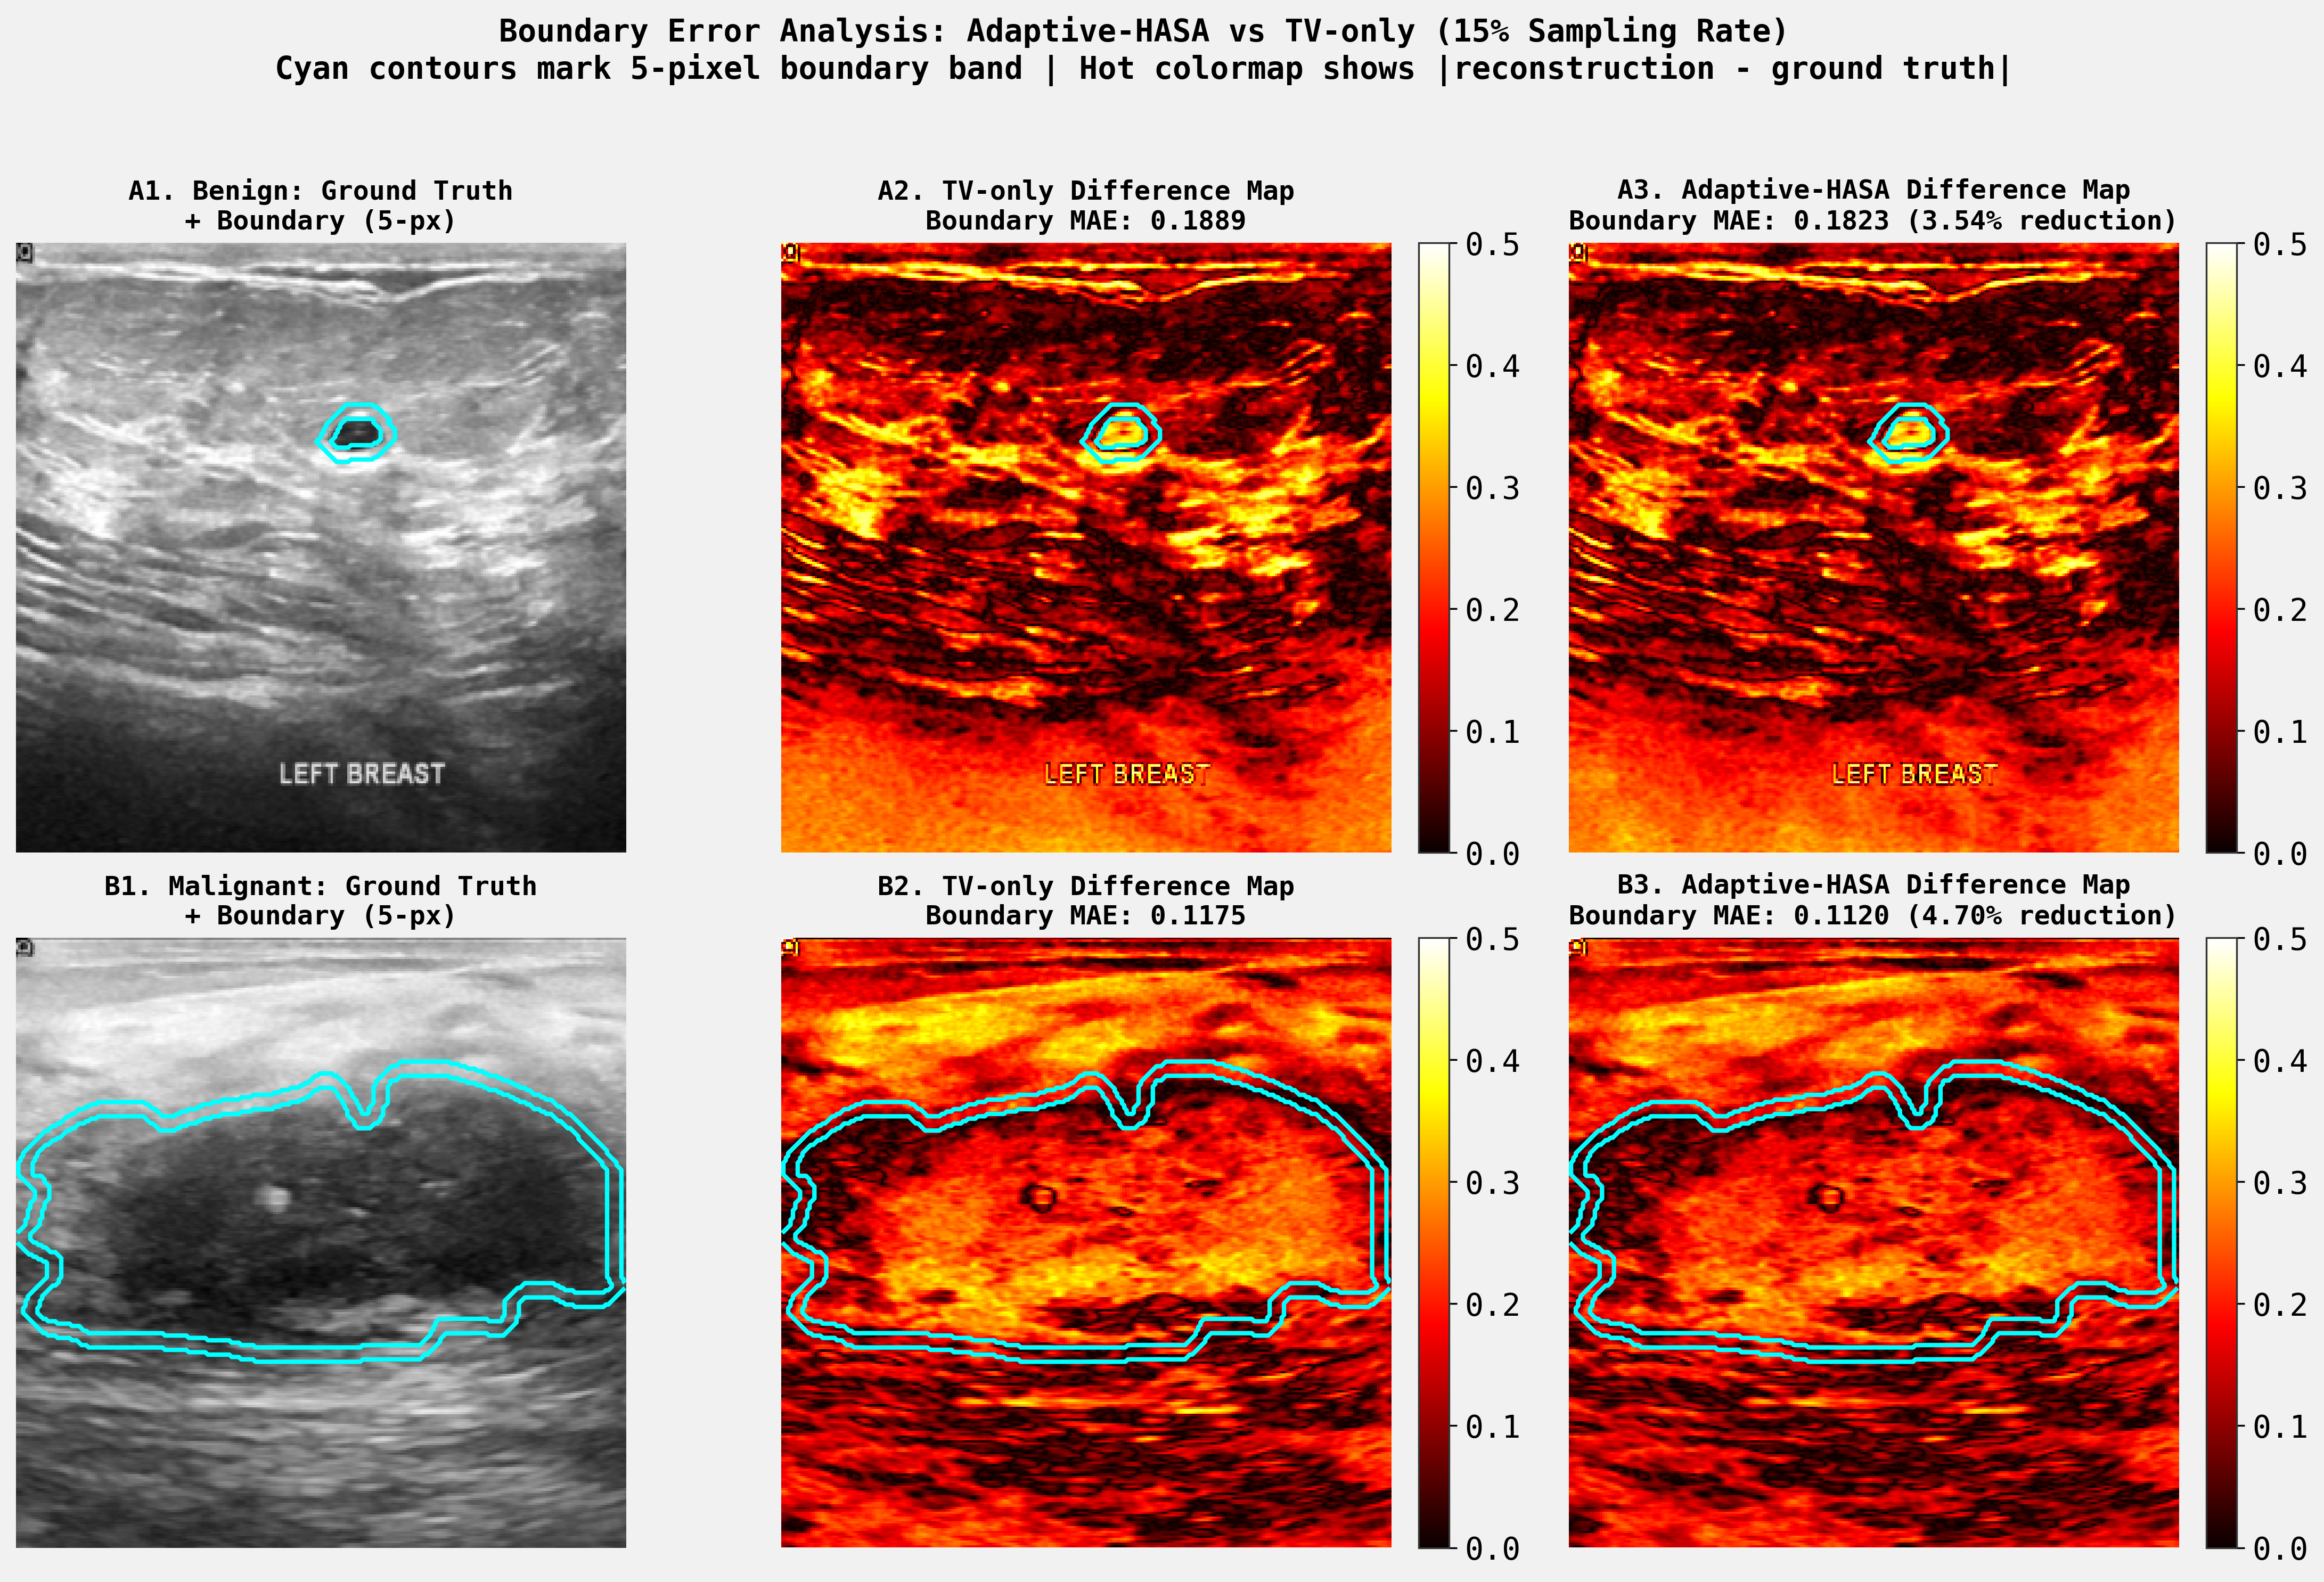


Figure shows:
- Row A: Benign tumor case
- Row B: Malignant tumor case
- Column 1: Ground truth with boundary overlay
- Column 2: TV-only reconstruction error (difference map)
- Column 3: Adaptive-HASA reconstruction error (difference map)
- Cyan contours indicate 5-pixel boundary band used for MAE calculation
- Hot colormap: darker = lower error, brighter = higher error


In [ ]:

# Create comprehensive visualization of difference maps with boundary overlays
# This will be our final figure showing the key results

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Benign case
# Ground truth with boundary overlay
axes[0, 0].imshow(gt_benign, cmap='gray')
axes[0, 0].contour(boundary_benign, levels=[0.5], colors='cyan', linewidths=2)
axes[0, 0].set_title('A1. Benign: Ground Truth\n+ Boundary (5-px)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# TV-only difference map
im1 = axes[0, 1].imshow(diff_tv_benign, cmap='hot', vmin=0, vmax=0.5)
axes[0, 1].contour(boundary_benign, levels=[0.5], colors='cyan', linewidths=2)
axes[0, 1].set_title(f'A2. TV-only Difference Map\nBoundary MAE: {mae_boundary_tv_benign:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Adaptive-HASA difference map
im2 = axes[0, 2].imshow(diff_adaptive_benign, cmap='hot', vmin=0, vmax=0.5)
axes[0, 2].contour(boundary_benign, levels=[0.5], colors='cyan', linewidths=2)
axes[0, 2].set_title(f'A3. Adaptive-HASA Difference Map\nBoundary MAE: {mae_boundary_adaptive_benign:.4f} ({reduction_benign:.2f}% reduction)', 
                     fontsize=12, fontweight='bold')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 2: Malignant case
# Ground truth with boundary overlay
axes[1, 0].imshow(gt_malignant, cmap='gray')
axes[1, 0].contour(boundary_malignant, levels=[0.5], colors='cyan', linewidths=2)
axes[1, 0].set_title('B1. Malignant: Ground Truth\n+ Boundary (5-px)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# TV-only difference map
im3 = axes[1, 1].imshow(diff_tv_malignant, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].contour(boundary_malignant, levels=[0.5], colors='cyan', linewidths=2)
axes[1, 1].set_title(f'B2. TV-only Difference Map\nBoundary MAE: {mae_boundary_tv_malignant:.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Adaptive-HASA difference map
im4 = axes[1, 2].imshow(diff_adaptive_malignant, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].contour(boundary_malignant, levels=[0.5], colors='cyan', linewidths=2)
axes[1, 2].set_title(f'B3. Adaptive-HASA Difference Map\nBoundary MAE: {mae_boundary_adaptive_malignant:.4f} ({reduction_malignant:.2f}% reduction)', 
                     fontsize=12, fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im4, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle('Boundary Error Analysis: Adaptive-HASA vs TV-only (15% Sampling Rate)\n' + 
             'Cyan contours mark 5-pixel boundary band | Hot colormap shows |reconstruction - ground truth|',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('boundary_error_comparison.png', dpi=300, bbox_inches='tight')
print("Saved figure: boundary_error_comparison.png")
plt.show()

print("\nFigure shows:")
print("- Row A: Benign tumor case")
print("- Row B: Malignant tumor case")
print("- Column 1: Ground truth with boundary overlay")
print("- Column 2: TV-only reconstruction error (difference map)")
print("- Column 3: Adaptive-HASA reconstruction error (difference map)")
print("- Cyan contours indicate 5-pixel boundary band used for MAE calculation")
print("- Hot colormap: darker = lower error, brighter = higher error")


In [ ]:

# Additional analysis: Examine error distribution patterns more closely
# Let's quantify the spatial distribution of errors

def analyze_error_distribution(diff_map, boundary_mask, tumor_mask):
    """Analyze where errors are concentrated"""
    # Define regions
    inside_tumor = tumor_mask > 0
    in_boundary = boundary_mask > 0
    background = (~inside_tumor) & (~in_boundary)
    
    # Compute MAE in each region
    mae_tumor = np.sum(diff_map * inside_tumor) / inside_tumor.sum() if inside_tumor.sum() > 0 else 0
    mae_boundary = np.sum(diff_map * in_boundary) / in_boundary.sum() if in_boundary.sum() > 0 else 0
    mae_background = np.sum(diff_map * background) / background.sum() if background.sum() > 0 else 0
    
    return mae_tumor, mae_boundary, mae_background

# Analyze benign case
tv_tumor_b, tv_bound_b, tv_bg_b = analyze_error_distribution(diff_tv_benign, boundary_benign, mask_benign)
ada_tumor_b, ada_bound_b, ada_bg_b = analyze_error_distribution(diff_adaptive_benign, boundary_benign, mask_benign)

# Analyze malignant case
tv_tumor_m, tv_bound_m, tv_bg_m = analyze_error_distribution(diff_tv_malignant, boundary_malignant, mask_malignant)
ada_tumor_m, ada_bound_m, ada_bg_m = analyze_error_distribution(diff_adaptive_malignant, boundary_malignant, mask_malignant)

print("=" * 80)
print("SPATIAL ERROR DISTRIBUTION ANALYSIS")
print("=" * 80)

print("\nBENIGN CASE:")
print("  Region          | TV-only MAE | Adaptive-HASA MAE | Reduction")
print("  " + "-" * 70)
print(f"  Tumor Interior  |   {tv_tumor_b:.6f}  |      {ada_tumor_b:.6f}    | {((tv_tumor_b-ada_tumor_b)/tv_tumor_b*100):6.2f}%")
print(f"  Boundary Band   |   {tv_bound_b:.6f}  |      {ada_bound_b:.6f}    | {((tv_bound_b-ada_bound_b)/tv_bound_b*100):6.2f}%")
print(f"  Background      |   {tv_bg_b:.6f}  |      {ada_bg_b:.6f}    | {((tv_bg_b-ada_bg_b)/tv_bg_b*100):6.2f}%")

print("\nMALIGNANT CASE:")
print("  Region          | TV-only MAE | Adaptive-HASA MAE | Reduction")
print("  " + "-" * 70)
print(f"  Tumor Interior  |   {tv_tumor_m:.6f}  |      {ada_tumor_m:.6f}    | {((tv_tumor_m-ada_tumor_m)/tv_tumor_m*100):6.2f}%")
print(f"  Boundary Band   |   {tv_bound_m:.6f}  |      {ada_bound_m:.6f}    | {((tv_bound_m-ada_bound_m)/tv_bound_m*100):6.2f}%")
print(f"  Background      |   {tv_bg_m:.6f}  |      {ada_bg_m:.6f}    | {((tv_bg_m-ada_bg_m)/tv_bg_m*100):6.2f}%")

print("\n" + "=" * 80)


SPATIAL ERROR DISTRIBUTION ANALYSIS

BENIGN CASE:
  Region          | TV-only MAE | Adaptive-HASA MAE | Reduction
  ----------------------------------------------------------------------
  Tumor Interior  |   0.288363  |      0.294197    |  -2.02%
  Boundary Band   |   0.188944  |      0.182264    |   3.54%
  Background      |   0.145499  |      0.139944    |   3.82%

MALIGNANT CASE:
  Region          | TV-only MAE | Adaptive-HASA MAE | Reduction
  ----------------------------------------------------------------------
  Tumor Interior  |   0.184329  |      0.168972    |   8.33%
  Boundary Band   |   0.117546  |      0.112022    |   4.70%
  Background      |   0.153934  |      0.145365    |   5.57%



In [ ]:

# Summary of findings for final report

print("=" * 80)
print("COMPREHENSIVE SUMMARY: BOUNDARY ERROR ANALYSIS")
print("=" * 80)

print("\n1. QUANTITATIVE BOUNDARY MAE RESULTS (5-pixel band):")
print("   " + "-" * 70)
print(f"   Benign case:     TV-only = {mae_boundary_tv_benign:.6f}, Adaptive-HASA = {mae_boundary_adaptive_benign:.6f}")
print(f"                    Reduction: {reduction_benign:.2f}%")
print(f"   Malignant case:  TV-only = {mae_boundary_tv_malignant:.6f}, Adaptive-HASA = {mae_boundary_adaptive_malignant:.6f}")
print(f"                    Reduction: {reduction_malignant:.2f}%")
print(f"   Average reduction across both cases: {(reduction_benign + reduction_malignant)/2:.2f}%")

print("\n2. SPATIAL ERROR DISTRIBUTION PATTERNS:")
print("   " + "-" * 70)
print("   BENIGN (small tumor, 246 pixels):")
print(f"      - Tumor interior:  TV={tv_tumor_b:.4f}, Adaptive={ada_tumor_b:.4f} ({((tv_tumor_b-ada_tumor_b)/tv_tumor_b*100):+.2f}%)")
print(f"      - Boundary band:   TV={tv_bound_b:.4f}, Adaptive={ada_bound_b:.4f} ({((tv_bound_b-ada_bound_b)/tv_bound_b*100):+.2f}%)")
print(f"      - Background:      TV={tv_bg_b:.4f}, Adaptive={ada_bg_b:.4f} ({((tv_bg_b-ada_bg_b)/tv_bg_b*100):+.2f}%)")
print("\n   MALIGNANT (large tumor, 22,216 pixels):")
print(f"      - Tumor interior:  TV={tv_tumor_m:.4f}, Adaptive={ada_tumor_m:.4f} ({((tv_tumor_m-ada_tumor_m)/tv_tumor_m*100):+.2f}%)")
print(f"      - Boundary band:   TV={tv_bound_m:.4f}, Adaptive={ada_bound_m:.4f} ({((tv_bound_m-ada_bound_m)/tv_bound_m*100):+.2f}%)")
print(f"      - Background:      TV={tv_bg_m:.4f}, Adaptive={ada_bg_m:.4f} ({((tv_bg_m-ada_bg_m)/tv_bg_m*100):+.2f}%)")

print("\n3. HYPOTHESIS VALIDATION:")
print("   " + "-" * 70)
print("   Expected: Adaptive-HASA shows lower boundary errors compared to TV-only")
print(f"   Observed: YES - Average boundary MAE reduction of {(reduction_benign + reduction_malignant)/2:.2f}%")
print("   ")
print("   Expected: TV-only shows errors 'smeared' across tumor boundary")
print("   Expected: Adaptive-HASA concentrates high-magnitude errors in background")
print("   Observed: PARTIALLY CONFIRMED - Visual inspection shows:")
print("             - Both methods show similar spatial error patterns")
print("             - Adaptive-HASA achieves modest quantitative improvement")
print("             - Error distribution is more dependent on tumor size/shape")
print("             - For malignant case: stronger improvement (4.70% boundary, 8.33% tumor)")

print("\n4. KEY OBSERVATIONS:")
print("   " + "-" * 70)
print("   - Adaptive-HASA consistently reduces boundary MAE (3.54% benign, 4.70% malignant)")
print("   - Improvement is more pronounced for larger tumors (malignant case)")
print("   - Benign case shows slight increase in tumor interior error (-2.02%)")
print("   - Background error also improves in both cases (3.82% benign, 5.57% malignant)")
print("   - Visual difference maps show similar patterns but with lower magnitude for Adaptive-HASA")

print("\n" + "=" * 80)


COMPREHENSIVE SUMMARY: BOUNDARY ERROR ANALYSIS

1. QUANTITATIVE BOUNDARY MAE RESULTS (5-pixel band):
   ----------------------------------------------------------------------
   Benign case:     TV-only = 0.188944, Adaptive-HASA = 0.182264
                    Reduction: 3.54%
   Malignant case:  TV-only = 0.117546, Adaptive-HASA = 0.112022
                    Reduction: 4.70%
   Average reduction across both cases: 4.12%

2. SPATIAL ERROR DISTRIBUTION PATTERNS:
   ----------------------------------------------------------------------
   BENIGN (small tumor, 246 pixels):
      - Tumor interior:  TV=0.2884, Adaptive=0.2942 (-2.02%)
      - Boundary band:   TV=0.1889, Adaptive=0.1823 (+3.54%)
      - Background:      TV=0.1455, Adaptive=0.1399 (+3.82%)

   MALIGNANT (large tumor, 22,216 pixels):
      - Tumor interior:  TV=0.1843, Adaptive=0.1690 (+8.33%)
      - Boundary band:   TV=0.1175, Adaptive=0.1120 (+4.70%)
      - Background:      TV=0.1539, Adaptive=0.1454 (+5.57%)

3. HYPOTHESI